# Condensator Ontwerpopdracht

Bij het vak elektromagnetisme zullen jullie in de eerste paar weken diep ingaan op de elektrostatica. Parallel hieraan zullen we bij het vak DEF-D, naast de fysieke ontwerpopdrachten en colleges, deze simulatie-ontwerpopdracht behandelen. Deze simulatie-opdracht is weer nauw verwoven met de tweede fysieke ontwerpopdracht die in week 3.3 gegeven wordt. Je moet het grootste deel van deze simulatie opdracht afronden voordat je aan de fysieke ontwerpopdracht van week 3.3 begint. Het laatste stuk van deze simulatie opdracht maak je na afloop van de fysieke opdracht. De deadline voor het inleveren van deze simulatie-opdracht is in week 3.4

Je werkt bij deze opdracht in teams die wij indelen. Zoek op Brightspace op met wie je samenwerkt en leg via email contact. Maak goede afspraken over hoe je samen gaat werken.

In deze simulatie opdracht beginnen we met een aantal simulaties van verschillende situaties, die jullie daarna zullen interpreteren. Daarna zal wat essentiële voorbereiding op de tweede fysieke ontwerpopdracht besproken worden. En als laatste zal dieper ingegaan worden op hoe jullie metingen van de tweede ontwerpopdracht afwijken van de theorie.

De opdracht bestaat uit de volgende sub-opdrachten die je moet doen voordat je begint aan de fysieke ontwerpopdracht van week 3.3:
1) Een puntlading in de oorsprong.
2) Een uniform geladen schijf bestaande uit puntladingen.
3) Een geladen schijf op een constant potentiaal.
4) Twee geleidende platen op potentiaal $V_1$ and $-V_1$.
5) Voorbereidende opdracht voor de DEF ontwerpopdracht.

Na de fysieke ontwerpopdracht van week 3.3 kan je ten slotte het laatste deel doen:

6) Reflectie opdracht voor na de fysieke ontwerpopdracht.

De opdracht wordt volledig online gedaan, er zullen hiervoor dus ook geen specifieke werkcolleges voor zijn ingeroosterd. Als jullie vragen hebben kunnen jullie die mailen naar het DEF e-mailadres: DEF-TNW@tudelft.nl. Deze opdracht wordt in week 3.4 beoordeeld en herkansingen zijn in week 3.5, zie de studiehandleiding voor details.
   
Technische Instructies:
- Git clone (als nog niet gedaan) het DEF repo en maak een branch voor werken aan deze opdracht. Nodig je groepsgenoot uit als collaborator. Hiervoor staat een manual op brightspace.
- Dit notebook maakt gebruik van een aantal functies die in het bestand ```functions_electrostatics.py``` staan. Dit bestand moet in dezelfde map (folder) staan als dit notebook. Als je git clone doet, gaat dat automatisch goed, maar verplaats dit notebook dus niet naar een andere map, mail het niet naar een mede-student, etc. Als je niet weet wat een map (folder) en een bestand is, bekijk dan [deze tutorial](https://teachbooks.io/files-and-folders/EN/intro.html).

Onderwijs Instructies:
- Beantwoord de vragen die in dit notebook voor komen direct in dit notebook.
- Als je iets moet printen op het scherm als antwoord op een vraag, doe dit op een gestructureerde manier met als dat relevant is de eenheid erbij, zoals je geleerd is bij het Inleidend Practicum.
- Vermijd 'hardcoden' waar mogelijk.
- Bij elke code cel staat aangegeven of jij hem moet aanpassen of alleen runnen. Lees bij cellen die je moet runnen, maar niet hoeft aan te passen, goed de code door om daarvan te leren en te gebruiken in de cellen die je wel moet aanpassen.

Elektrostatica Opmerkingen:
- In deze opdracht zullen jullie verschillende problemen bestuderen die as-symmetrie hebben. De opdrachten zullen daardoor, cilindrische coördinaten ($r$,$\phi$,$z$) gebruiken, waarbij $r$ de afstand tot de $z$ as is, $z$ de hoogte en $\phi$ de hoek met de $x$-as. Alle gebruikte problemen zullen ook in de $\phi$ richting symmetrisch zijn en die coördinaat zal dus niet uitmaken.
- Voor elke sub-opdracht zal eerst het potentiaal bepaald worden en daarna zal het elektrische veld bepaald worden met de "finite difference" methode. Dit is een methode om de afgeleide te nemen van een dataset. Deze methode is geen onderdeel van de leerdoelen van het vak en komt later in je studie aan bod. We gebruiken "finite difference" hier als gereedschap en als voorbeeld van wat je later nog tegen gaat komen.



Vul de informatie in deze cel in:

| Groep: 46  |  |
| :-------------|:-------------|
| Oscar Wesdorp| 6578365|
| Querijn Sanson| Student Studienummer 6562507|

In [64]:
# Run deze cel, pas deze niet aan
import numpy as np
import matplotlib.pyplot as plt
from functions_electrostatics import *
#from IPython import display
from IPython.display import Image, display


epsilon0 = 8.854e-12  # permittiviteit van vacuum (F/m)

"""============================================================================================
We first define the size of the domain of calculation and spatial discretization of the domain
"""

# Grid van het rekendomein; het veld wordt berekend in het (r,z)-vlak (asymmetrie):
width_domain = 5  # (m)
height_domain = width_domain  # maximum afstand van de schijf tot de grond, boven en beneden (m)
grid_step = 0.1  # grid stap grootte (m)

### 1) Een puntlading in de oorsprong

In deze opdracht gaan we in op een numerieke benadering van het potentiaal en elektrische veld rond een puntlading in de oorsprong. 

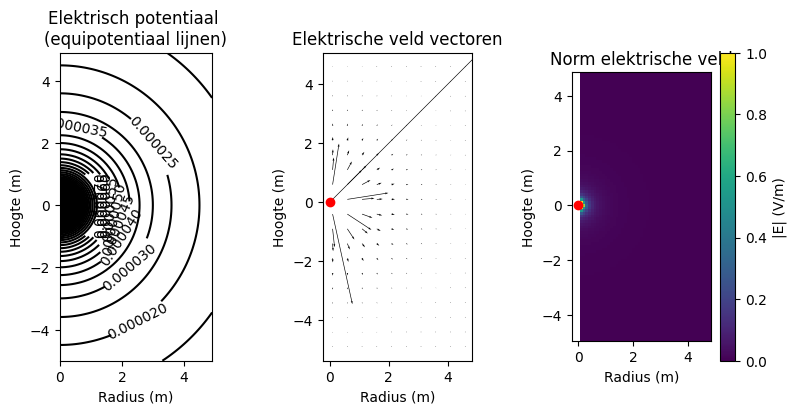

In [65]:
# Run deze cel, pas de cel niet aan
charge_one_point = 1e-14  # lading van 1 punt (C)

r, z, B = initialize_plane_grid_for_pt_charge_at_origin(height_domain, width_domain, grid_step)
V = calculate_V_point_charge_at_origin(charge_one_point, r, z)

Er, Ez, normE = compute_E_pt_charge(V, B, grid_step)  # gebruik de centered finite-difference method
# met Er de r-component, Ez de z-component en normE de norm van het elektrische veld

r_for_E = r[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de r-dimensie
z_for_E = z[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de z-dimensie

plot_results_pt_charge_at_origin(Ez, Er, normE, V, r, z, grid_step)


##### Vraag 1a Het potentiaal rond een puntlading

1. Bepaal welke index correspondeert met $z = 0$ m.
2. Plot de log van het potentiaal tegen de log van de straal.
3. Fit de log van het potentiaal met de log van de straal.
4. Print het exponent op een nette manier.

Index voor z ≈ 0: 50
Werkelijke z-waarde op die index: -1.7763568394002505e-14


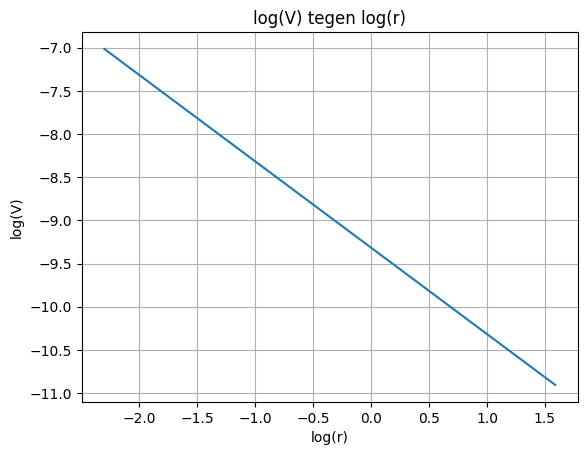

Het exponent in de relatie V ∝ r^n is n = -1.000


In [66]:
###
###Hier jouw code###

index_z0 = np.argmin(np.abs(z - 0.0))
print("Index voor z ≈ 0:", index_z0)
print("Werkelijke z-waarde op die index:", z[index_z0])


V_slice = V[index_z0, :]      # potentiaal op z = 0
r_slice = r       
plt.figure()
plt.plot(np.log(r_slice[1:]), np.log(V_slice[1:]))  # r=0 vermijden
plt.xlabel("log(r)")
plt.ylabel("log(V)")
plt.title("log(V) tegen log(r)")
plt.grid(True)
plt.show()
coeffs = np.polyfit(np.log(r_slice[1:]), np.log(V_slice[1:]), 1)
slope, intercept = coeffs
print(f"Het exponent in de relatie V ∝ r^n is n = {slope:.3f}")
###

##### Vraag 1b Het elektrische veld rond een puntlading
1. Voer van vraag 1a 2 tot 4 uit voor het elektrische veld.

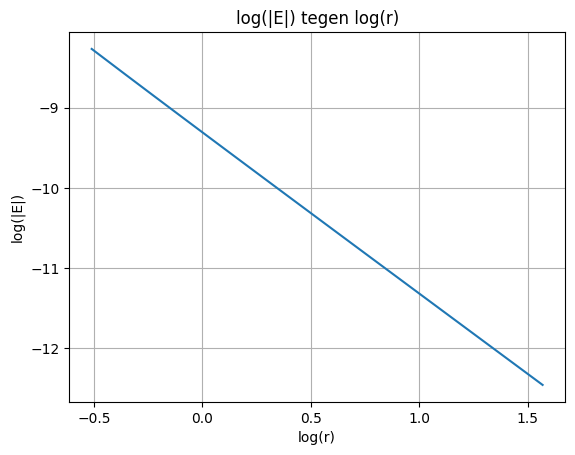

Het exponent in de relatie |E| ∝ r^n is n = -2.009


In [67]:
###
###Hier jouw code###
index_z0_E = np.argmin(np.abs(z_for_E - 0.0))
E_slice = normE[index_z0_E, :]
r_slice_E = r_for_E

# Filter: r > 0 én E > 0
mask_E = (r_slice_E > 0.5) & (E_slice > 0)


log_r_E = np.log(r_slice_E[mask_E])
log_E   = np.log(E_slice[mask_E])

plt.figure()
plt.plot(log_r_E, log_E)
plt.xlabel("log(r)")
plt.ylabel("log(|E|)")
plt.title("log(|E|) tegen log(r)")
plt.grid(True)
plt.show()

coeffs_E = np.polyfit(log_r_E, log_E, 1)
slope_E, intercept_E = coeffs_E

print(f"Het exponent in de relatie |E| ∝ r^n is n = {slope_E:.3f}")

###

### 2) Een uniform geladen schijf bestaande uit puntladingen

In de code hieronder wordt een geladen schijf gemaakt via het superpositie principe. Dit wordt gedaan door een rooster van punten in de ruimte te creëren, alle punten die voldoen aan $z = 0$ m en $r < R$ krijgen een lading charge_one_point en vanuit hier wordt het potentiaal bepaald. Hier is de $z$-as de as van de schijf en de r as de afstand tot de $z$-as.



In [68]:
# In vraag 2.1 wordt naar deze cel verwezen.
disk_radius = 3  # (m)
grid_step = 0.1  # (m)
z_coord_DISK = 0  # (m) positie van de schijf op de z-as
inter_charge_distance = grid_step  # (m) afstand tussen punt ladingen

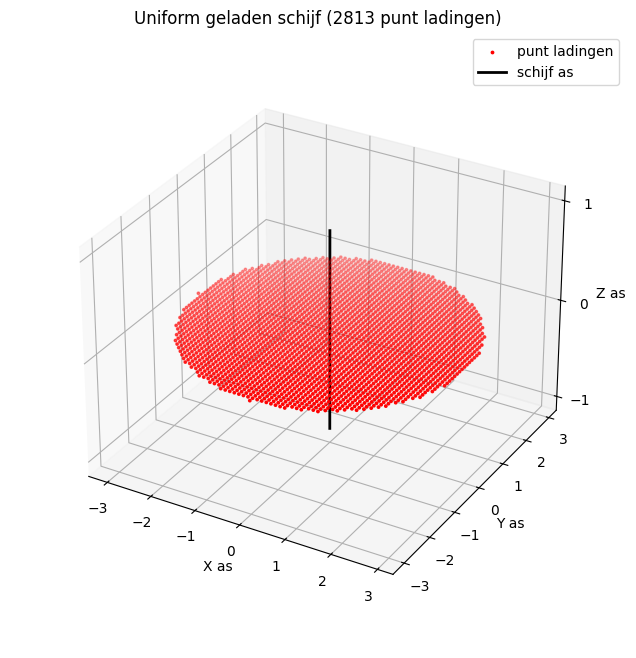

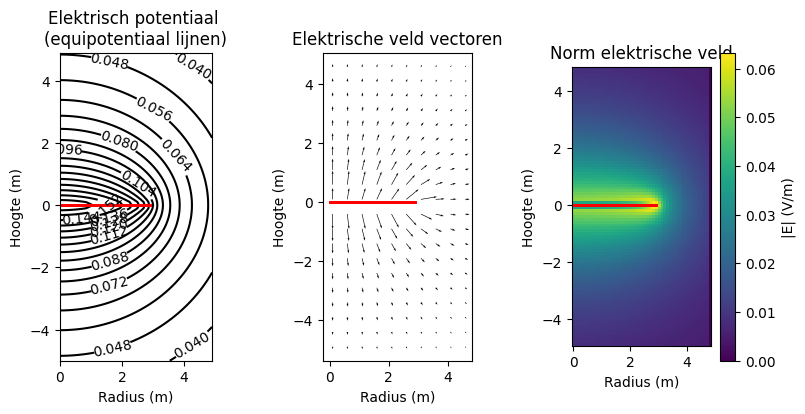

In [69]:
# Kies uit deze cel een van de variabelen en verander die in de cel hierboven pas deze cel zelf niet aan.
r, z, B = initialize_plane_grid_for_uniformly_charged_disk(height_domain, width_domain, grid_step)

idx_z_zero = np.where(abs(z) < 1e-10)[0]
z_coord_DISK = 0  # (m) positie van de schijf op de z-as
inter_charge_distance = grid_step  # (m) afstand tussen punt ladingen

V, number_point_charges_on_disk = calculate_V_disk_at_origin_uniform_surface_charge_density(z_coord_DISK, charge_one_point, disk_radius, inter_charge_distance, r, z)
Er, Ez, normE = compute_E_disk(V, B, grid_step)  # gebruik de centered finite-difference method

r_for_E = r[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de r-dimensie
z_for_E = z[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de z-dimensie

plot_results_disk(Ez, Er, normE, V, r, z, grid_step, disk_radius, z_coord_DISK, z_coord_DISK)

#### Vraag 2a

In deze vraag gaan jullie achterhalen wat de variabelen die aan het begin van opgave 2 worden geïnitialiseerd betekenen voor de nauwkeurigheid en snelheid van de code.
Pas voor deze vraag de code die net onder het kopje vraag 2 staat aan. Run dan die cel en de cel daaronder opnieuw om het resultaat van je aanpassing te zien.
1. Wat betekent de disk radius variabele die in de bovenste cel geïnitialiseerd wordt, wat gebeurt er als disk radius naar 0 gaat?
2. Wat betekent gridstep en wat voor impact heeft deze variabele op de simulatie?
3. Pak uit de tweede code cel in opdracht 2 een andere variabelen en onderzoek wat deze variabele doet en wat voor impact die heeft op de simulatie.

##### Antwoorden 2a
1 De disk radius variabele bepaalt hoe ver het elektrische veld uitbreid naar de zijkant. Als deze naar nul gaat wordt het potentiaal steeds compacter naar het centrum en daarnaast neemt de totale lading ook af.
2 De grid step is de afstand waartussen de simulatie puntladingen naast elkaar zet. Als deze lager wordt, wordt de nauwkeurigheid van punten binnen de schijf hoger. Als deze heel klein wordt dan duurt de simulatie heel lang.
3 Als je de height en width van het domein kleiner maakt zorgt dat ervoor dat de vectoren in het elektrische veld groter worden en dat de hoogte van de norm groter wordt.

#### Vraag 2b Oppervlakte lading

Pas de cel die je in vraag 2a hebt aangepast weer aan naar de originele waardes. Run hierna alle code cellen na vraag 2 weer opnieuw.
Het aantal punten dat gebruikt wordt om de schijf te creëren is number_point_charges_on_disk en de lading van een punt is charge_one_point in Coulomb.
1. Bereken en print de ladingsdichtheid $\sigma$ met een correcte eenheid.

In [70]:
###
###Hier jouw code###
totale_lading = number_point_charges_on_disk * charge_one_point
area_disk = np.pi * (disk_radius**2)
sigma = totale_lading / area_disk

epsilon_0 = 8.854e-12
print(f"Ladingsdichtheid sigma: {sigma:.2e} C/m^2")
###

Ladingsdichtheid sigma: 9.95e-13 C/m^2


##### Vraag 2c

1. Plot het elektrische potentiaal langs de $r$ as ($z = 0$ m).
2. Plot het potentiaal op de rand van de schijf in hetzelfde figuur $V = \sigma R/(\pi \epsilon_0)$
(bekijk probleem 2.51 in het Griffiths' boek)
3. Plot het potentiaal in het centrum van de schijf in hetzelfde figuur $V = \sigma R/(2 \epsilon_0)$

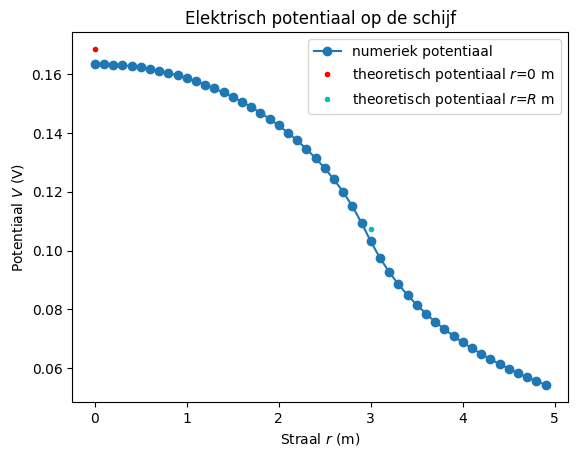

[[0.04670257 0.04669585 0.04667637 ... 0.03625655 0.03593352 0.03561154]
 [0.04751702 0.04751    0.04748964 ... 0.03665525 0.03632173 0.03598945]
 [0.04835819 0.04835085 0.04832955 ... 0.03706004 0.03671563 0.03637266]
 ...
 [0.04922731 0.04921963 0.04919735 ... 0.03747094 0.03711522 0.03676118]
 [0.04835819 0.04835085 0.04832955 ... 0.03706004 0.03671563 0.03637266]
 [0.04751702 0.04751    0.04748964 ... 0.03665525 0.03632173 0.03598945]]


In [ ]:
# Vul deze code aan zodat deze vraag 2.3 beantwoord.
idx_z_zero = np.argmin(np.abs(z))
if idx_z_zero >= V.shape[1]:
    idx_z_zero = V.shape[1] - 1

V_0 = sigma * disk_radius / (2 * epsilon_0)
V_R = sigma * disk_radius / (np.pi * epsilon_0)
r_R = disk_radius

plt.figure()
plt.title(f"Elektrisch potentiaal op de schijf")
plt.plot(r, V[idx_z_zero, :], "o-", label="numeriek potentiaal")
plt.plot(0, V_0, "r.", label="theoretisch potentiaal $r$=0 m")
plt.plot(r_R, V_R, "c.", label="theoretisch potentiaal $r$=$R$ m")
plt.legend()
plt.xlabel("Straal $r$ (m)")
plt.ylabel("Potentiaal $V$ (V)")
plt.show()




#### Vraag 2d

Het theoretische potentiaal op de as van een hele grote schijf ($R>>z$) is:
$V(z, r=0) = \frac{\sigma}{2\epsilon_0} \big( R - |z|\big)$
zie probleem 2.26 in het Griffiths boek.
1. Plot het numeriek berekend elektrische potentiaal op de $z$-as ($r=0$).
2. Plot het theoretische component van het potentiaal op de as van een schijf met ladingsdichtheid $\sigma$.
3. Sla deze plot op.


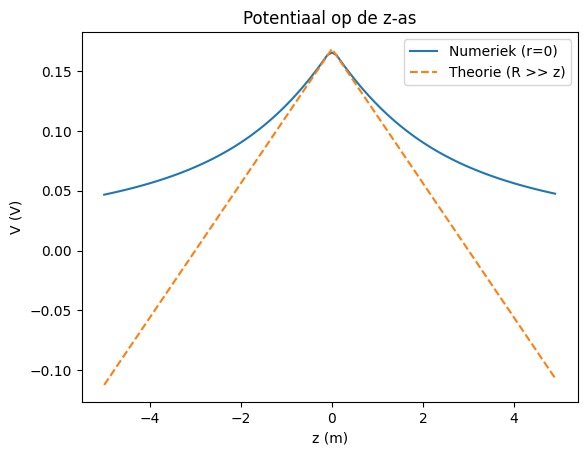

In [72]:
###
###Hier jouw code###
#numeriek berekend elektrisch potentiaal
idx_r_zero = np.argmin(np.abs(r))
V_z_as = V[:,idx_r_zero]

# Theoretische component
V_theo_z = (sigma / (2 * epsilon_0)) * (disk_radius - np.abs(z))

plt.figure()
plt.plot(z, V_z_as, label="Numeriek (r=0)")
plt.plot(z, V_theo_z, '--', label="Theorie (R >> z)")
plt.title("Potentiaal op de z-as")
plt.xlabel("z (m)")
plt.ylabel("V (V)")
plt.legend()
plt.savefig("plot_2d.png")
###

#### Vraag 2e

Het theoretische elektrische veld van een oneindig geladen oppervlakte is $|E| = \sigma/(2 \epsilon_0)$ (zie Example 2.5 in het Griffith boek).
1. Plot het z-component van het numeriek berekende elektrische veld op de as van de schijf ($r=0$).
2. Plot het theoretische elektrische veld voor een oneindig geladen oppervlak.
3. Sla deze plot ook op.

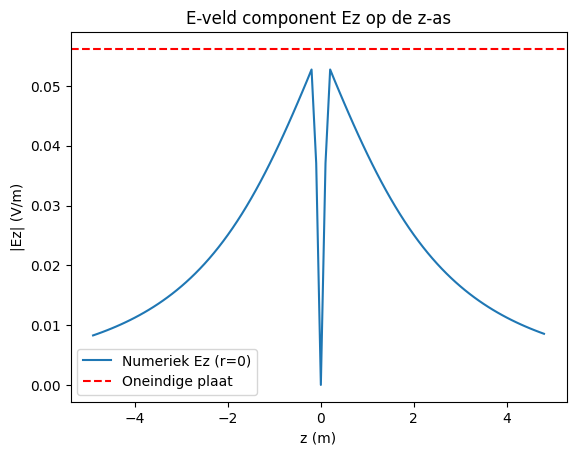

In [73]:
###
###Hier jouw code###
#z-component
idx_r_zero_E = np.argmin(np.abs(r_for_E))
Ez_z_as = Ez[:,idx_r_zero_E]

#oneindig geladen oppervlak
E_inf_plaat = sigma / (2 * epsilon_0)

plt.figure()
plt.plot(z_for_E, np.abs(Ez_z_as), label="Numeriek Ez (r=0)")
plt.axhline(y=E_inf_plaat, color='r', linestyle='--', label="Oneindige plaat")
plt.title("E-veld component Ez op de z-as")
plt.xlabel("z (m)")
plt.ylabel("|Ez| (V/m)")
plt.legend()
plt.savefig("plot_2e.png")
###

#### Vraag 2f
1. Waar benadert het elektrische veld van een uniform geladen schijf dat van een oneindig geladen plaat?
2. Beschrijf en verklaar de verschillen die je opvallen in de plot die je bij vraag 2e hebt gemaakt.

##### Antwoorden 2f
1. Het veld van een uniform geladen schijf benadert dat van een oneindig geladen plaat heel dicht bij het oppervlak in het midden.
2. Je ziet dat naarmate z groter wordt het elektische veld afzwakt. Daarnaast zie je ook bij nul een dip in het elektrische veld.


#### Vraag 2g

1. Pas helemaal bovenaan in vraag 2 de straal van de schijf aan.
2. Voer dan vragen 2d en 2e opnieuw uit.
3. Voeg de opgeslagen figuren hieronder toe.
4. Beschrijf de verschillen tussen de twee verschillende stralen.

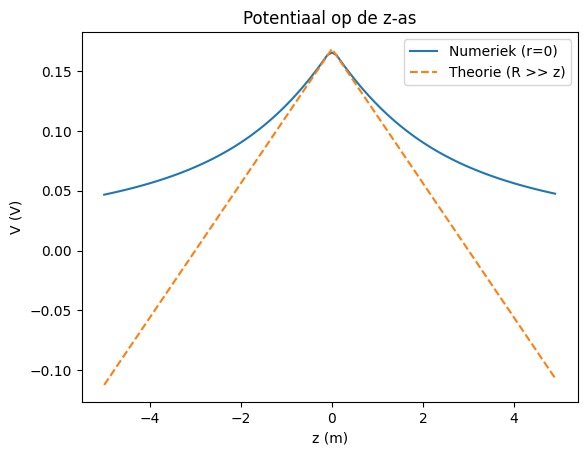

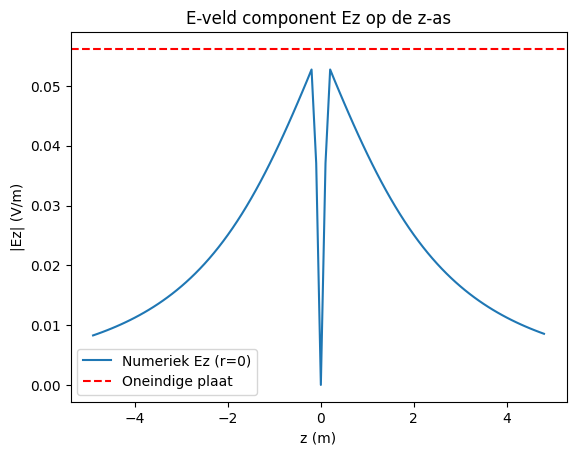

In [74]:
###
###Jouw code hier###
#2d
#numeriek berekend elektrisch potentiaal
idx_r_zero = np.argmin(np.abs(r))
V_z_as = V[:,idx_r_zero]

# Theoretische component
V_theo_z = (sigma / (2 * epsilon_0)) * (disk_radius - np.abs(z))

plt.figure()
plt.plot(z, V_z_as, label="Numeriek (r=0)")
plt.plot(z, V_theo_z, '--', label="Theorie (R >> z)")
plt.title("Potentiaal op de z-as")
plt.xlabel("z (m)")
plt.ylabel("V (V)")
plt.legend()
plt.savefig("plot_2d.2.png")

#2e
#z-component
idx_r_zero_E = np.argmin(np.abs(r_for_E))
Ez_z_as = Ez[:,idx_r_zero_E]

#oneindig geladen oppervlak
E_inf_plaat = sigma / (2 * epsilon_0)

plt.figure()
plt.plot(z_for_E, np.abs(Ez_z_as), label="Numeriek Ez (r=0)")
plt.axhline(y=E_inf_plaat, color='r', linestyle='--', label="Oneindige plaat")
plt.title("E-veld component Ez op de z-as")
plt.xlabel("z (m)")
plt.ylabel("|Ez| (V/m)")
plt.legend()
plt.savefig("plot_2e.2.png")
#display(Image("folder-name/image-name"))
###

##### Antwoorden 2g
Bij een hogere schaal ligt bij d de theoretische waarde dichter bij de numerieke waarde en bij e is het elektrische veld van de oneindige plaat groter geworden.

#### Vraag 2h
Het elektrische veld een afstand $z$ boven het midden van een uniform geladen schijf met een straal $R$ en oppervlakte lading $\sigma$ wordt gegeven door:
$$ \mathbf{E} = \frac{\sigma}{2\epsilon_0} \bigg[ 1- \frac{z}{\sqrt{R^2 + z^2}}\bigg] \hat{\mathbf{z}}$$
Zie probleem 2.6 in het boek van Griffith.

1. Wat moet de hoogte $z$ zijn boven de schijf zodat het elektrische veld door de schijf 10% is in vergelijking met dat van een oneindig geladen plaat?

Voeg hieronder je analytische uitwerking toe.

##### Antwoord 2h

$$E_{disk} = \frac{\sigma}{2\epsilon_0} \left[ 1 - \frac{z}{\sqrt{R^2 + z^2}} \right]$$

$$E_{plane} = \frac{\sigma}{2\epsilon_0}$$

$$\frac{\sigma}{2\epsilon_0} \left[ 1 - \frac{z}{\sqrt{R^2 + z^2}} \right] = 0,10 \cdot \frac{\sigma}{2\epsilon_0}$$

$$1 - \frac{z}{\sqrt{R^2 + z^2}} = 0,10$$

$$\frac{z}{\sqrt{R^2 + z^2}} = 0,90$$

$$\frac{z^2}{R^2 + z^2} = 0,81$$

$$z^2 = 0,81R^2 + 0,81z^2$$

$$0,19z^2 = 0,81R^2$$

$$z = \sqrt{\frac{0,81}{0,19}}R \approx 2,06 R$$

### 3) Een geladen schijf op een constant potentiaal

We zullen nu het verschil bestuderen tussen een uniform geladen schijf en een geleidende schijf die op een bepaald potentiaal gehouden wordt.
De code hieronder lost numeriek de laplace vergelijking op voor een geleidende schijf op een constant potentiaal. Hieruit volgt het potentiaal in de ruimte.

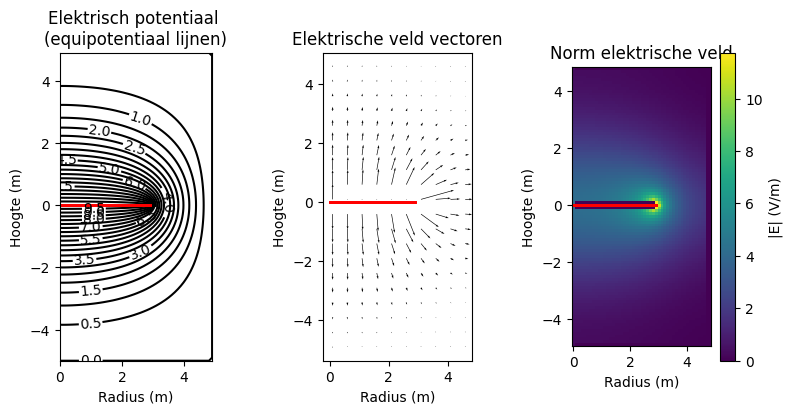

In [75]:
# Run deze cel pas deze niet aan.
V0 = 0  # electric potential at boundary of domain (V)

# Één schijf
z_pos_disk1 = 0  # z-coördinaat van de eerste geleidende schijf (m)
z_pos_disk2 = z_pos_disk1  # z-coördinaat van de tweede geleidende schijf (m)
V1 = 10  # elektrische potentiaal van de eerste geleidende schijf (V)

r, z, r_repmat, V, B, idx_R, idx_z1, idx_z2 = initialize_variables_Laplace(width_domain, disk_radius, height_domain, grid_step, z_pos_disk1, z_pos_disk2, V0, V1, V1)

"""--------------------------------------------------------------------
Veldberekening voor een geleidende schijf
"""
solve_Laplace_equation(V, B, r_repmat, grid_step, idx_z1, idx_z2, idx_R, V1, V1, 1e-3)
Er, Ez, normE = compute_E_disk(V,B,grid_step)
r_for_E = r[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de r-dimensie
z_for_E = z[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de z-dimensie

""""---------------------------------------------------------
Plot het berekende veld
"""
plot_results_disk(Ez, Er, normE, V, r, z, grid_step, disk_radius, z_pos_disk1, z_pos_disk2)

#### Vraag 3a: De simulatie van het elektrische veld van een geleidende schijf op constant potentiaal

1. Plot de elektrische veld sterkte op de as van de schijf.
2. Print de norm van het elektrische veld op de as heel dicht bij het midden van de schijf, zorg hier voor een nette opmaak.

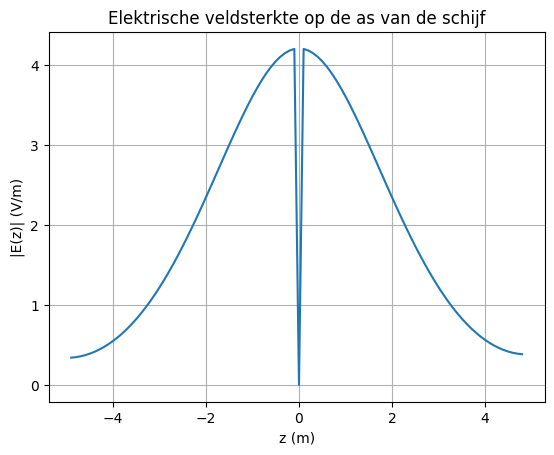

Norm van E op de as heel dichtbij het midden van de schijf is 4.202e+00 V/m


In [76]:
###
###Jouw code hier###
# Vind index voor r ≈ 0 (eerste punt in r_for_E)
index_r0 = 0

# Elektrisch veld langs de as (Ez-component)
E_axis = Ez[:, index_r0]      # veld langs z-as
z_axis = z_for_E              # bijbehorende z-waarden

plt.figure()
plt.plot(z_axis, np.abs(E_axis))
plt.xlabel("z (m)")
plt.ylabel("|E(z)| (V/m)")
plt.title("Elektrische veldsterkte op de as van de schijf")
plt.grid(True)
plt.show()

# Kies de as: r zo dicht mogelijk bij 0
index_r_axis = 0  # of np.argmin(np.abs(r_for_E - 0))

# Kies een z-punt net boven de schijf
# Stel dat de schijf in het vlak z = 0 ligt:
index_z0 = np.argmin(np.abs(z_for_E - 0.0))
index_z_above = index_z0 + 1   # één gridstap erboven

E_axis_above = normE[index_z_above, index_r_axis]

print(f"Norm van E op de as heel dichtbij het midden van de schijf is {E_axis_above:.3e} V/m")

###

#### Vraag 3b: De oppervlakte lading in het midden van een geleidende schijf op constant potentiaal

1. Met welke formule kan je de oppervlaktelading benaderen in het midden van de schijf($r=0$, $z=0$)? in een geleider geldt $\sigma$=$\epsilon_{0}E_\perp$
2. Print netjes de benadering van de oppervlakte lading in het midden van de schijf.

##### Antwoord 3b

*Geef in deze markdown cel je antwoord op 3b.1.*

In [77]:
#### Print met deze cel met een nette opmaak je antwoord op vraag 3b 2.
epsilon0 = 8.854e-12  # F/m
sigma_center = epsilon0 * E_axis_above

print(f"De benadering van de oppervlaktelading in het midden van de schijf is: {sigma_center:.3e} C/m^2")


De benadering van de oppervlaktelading in het midden van de schijf is: 3.720e-11 C/m^2


#### Vraag 3c: De oppervlaktelading van een geleidende schijf op constant potentiaal

De oppervlakte lading $\sigma(r)$ van een geleidende schijf met straal $R$ is niet uniform verdeeld over de schijf, maar wordt gegeven door (Problems 2.58 and 2.63 Griffiths 5th edition):
$$\sigma(r) = \frac{Q}{2 \pi R \sqrt{R^2 - r^2}}$$

1. Bereken de totale lading op de schijf met behulp van vraag 3a en 3b.
2. Vergelijk de oppervlakte lading in het centrum van de geleidende schijf met dat van een uniform geladen schijf met dezelfde totale lading.
3. Plot de oppervlakte lading van de geleidende schijf met de berekende lading $Q$, tussen $r = 0$ en $R$.
4. Plot in hetzelfde figuur de oppervlaktelading van een uniform geladen schijf met dezelfde lading $Q$.


Totale lading op de schijf is Q = 2.104e-09 C
σ(0) (geleidende schijf)     = 3.720e-11 C/m^2
σ_uniform (uniforme schijf) = 7.441e-11 C/m^2
Verhouding σ(0) / σ_uniform = 0.500


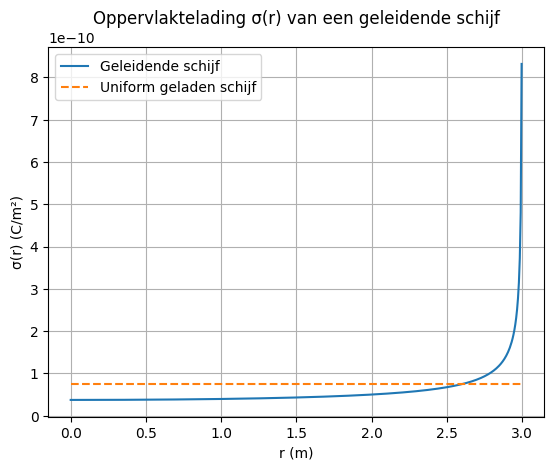

In [ ]:
###
###Jouw code hier###
#1
R = disk_radius                   

Q = 2 * np.pi * R**2 * sigma_center
print(f"Totale lading op de schijf is Q = {Q:.3e} C")

#2
sigma_uniform = Q / (np.pi * R**2)

print(f"σ(0) (geleidende schijf)     = {sigma_center:.3e} C/m^2")
print(f"σ_uniform (uniforme schijf) = {sigma_uniform:.3e} C/m^2")
print(f"Verhouding σ(0) / σ_uniform = {sigma_center / sigma_uniform:.3f}")

#3
r_vals = np.linspace(0, R*0.999, 500)  # tot net onder R om deling door 0 te vermijden
sigma_cond = Q / (2 * np.pi * R * np.sqrt(R**2 - r_vals**2))

plt.figure()
plt.plot(r_vals, sigma_cond, label="Geleidende schijf")
plt.xlabel("r (m)")
plt.ylabel("σ(r) (C/m²)")
plt.title("Oppervlaktelading σ(r) van een geleidende schijf")
plt.grid(True)

#4
sigma_uniform_line = np.full_like(r_vals, sigma_uniform)

plt.plot(r_vals, sigma_uniform_line, '--', label="Uniform geladen schijf")
plt.legend()
plt.show()

###

#### Vraag 3d: Het edge effect

1. Bepaal het maximum elektrische veld door de geleidende schijf in de simulatie.
2. Bepaal waar in de ruimte dit maximum zich bevindt.
3. Hoeveel hoger is dit maximum dan het elektrische veld in het midden van de schijf?
4. Print met een nette opmaak de waardes die je hier hebt berekend.
5. Leg uit wat de oorzaak van dit lokaal hoge elektrische veld is?


In [79]:
# Deze cel kan je gebruiken om van vraag 3c 1 tot en met 4 te beantwoorden.
#1
E_max = np.max(normE)

#2
# Vind indices van het maximum
idx_flat = np.argmax(normE)
i_z_max, i_r_max = np.unravel_index(idx_flat, normE.shape)

z_max = z_for_E[i_z_max]
r_max = r_for_E[i_r_max]

#3
index_z0 = np.argmin(np.abs(z_for_E - 0.0))
index_r_axis = 0
E_center = normE[index_z0, index_r_axis]

factor = E_max / E_center

#4
print(f"Maximale veldsterkte:              {E_max:.3e} V/m")
print(f"Locatie van E_max:                 r = {r_max:.3e} m, z = {z_max:.3e} m")
print(f"Veldsterkte in het midden (as):    {E_center:.3e} V/m")
print(f"Edge-effect factor (E_max / E_mid): {factor:.2f} keer zo groot")



Maximale veldsterkte:              1.175e+01 V/m
Locatie van E_max:                 r = 3.000e+00 m, z = 1.000e-01 m
Veldsterkte in het midden (as):    1.521e-05 V/m
Edge-effect factor (E_max / E_mid): 772488.59 keer zo groot


##### Antwoord 3d.5
Volgens de formule voor de oppervlakte lading ($\sigma$) wordt de lading steeds groter naarmate je dichter bij de rand komt.Het gaat naar oneindig als R=r.  de ladingsdichtheid (en dus het veld) divergeert dus naar de rand. Waardoor het elektrische veld zo groot is.
*Schrijf hier je argumentatie voor vraag 3d.5.*

### 4) Twee geleidende platen op potentiaal $V_1$ and $-V_1$

In de cel hieronder wordt weer op dezelfde manier als in opdracht 3 de laplace vergelijking van deze situatie opgelost.

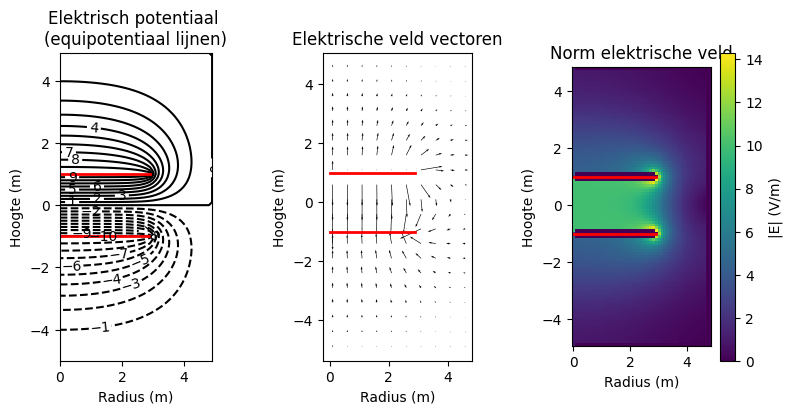

In [80]:
# Run deze cel en pas de cel aan in vraag 4f.
# Voor twee schijven
spacing_between_disks = 2  # (m)
z_pos_disk1 = spacing_between_disks/2  # z-coördinaat van de eerste geleidende schijf (m)
z_pos_disk2 = -spacing_between_disks/2  # z-coördinaat van de tweede geleidende schijf (m)
V1 = 10  # elektrische potentiaal van de eerste geleidende schijf (V)
V2 = -10  # elektrische potentiaal van de tweede geleidende schijf (V)

r, z, r_repmat, V, B, idx_R, idx_z1, idx_z2 = initialize_variables_Laplace(width_domain, disk_radius, height_domain, grid_step, z_pos_disk1, z_pos_disk2, V0, V1, V2)

"""--------------------------------------------------------------------
Veldberekening voor de twee geleidende schijven
"""
solve_Laplace_equation(V, B, r_repmat, grid_step, idx_z1, idx_z2, idx_R, V1, V2, 1e-3)
Er, Ez, normE = compute_E_disk(V, B, grid_step)
r_for_E = r[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de r-dimensie
z_for_E = z[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de z-dimensie

""""---------------------------------------------------------
Plot het berekende veld
"""
plot_results_disk(Ez, Er, normE, V, r, z, grid_step, disk_radius, z_pos_disk1, z_pos_disk2)


#### Vraag 4a: Het $z$-component van het numeriek berekende elektrische veld van twee geleidende platen

1. Plot het $z$-component van het numeriek berekende elektrische veld op de as van de schijven.


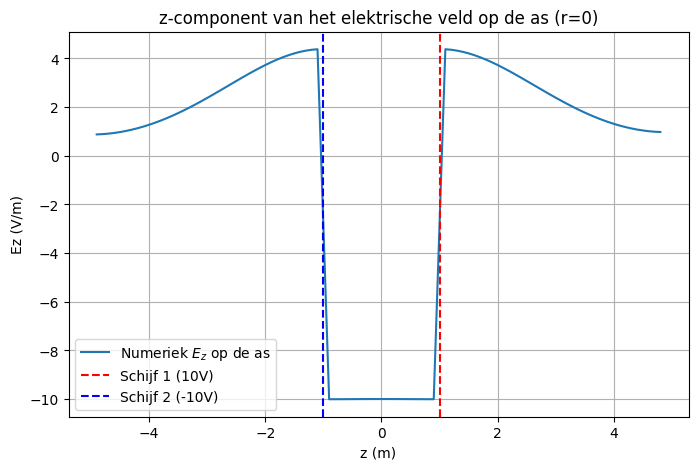

In [81]:
###
###your code here###
idx_r_zero_E = np.argmin(np.abs(r_for_E))
Ez_as = Ez[:,idx_r_zero_E]

plt.figure(figsize=(8,5))
plt.plot(z_for_E, Ez_as, label='Numeriek $E_z$ op de as')
plt.axvline(x=z_pos_disk1, color='r', linestyle='--', label='Schijf 1 (10V)')
plt.axvline(x=z_pos_disk2, color='b', linestyle='--', label='Schijf 2 (-10V)')
plt.title("z-component van het elektrische veld op de as (r=0)")
plt.xlabel("z (m)")
plt.ylabel("Ez (V/m)")
plt.legend()
plt.grid(True)
plt.show()
###

#### Vraag 4b: Verschillen tussen verschillende configuraties

1. Gegeven het potentiaal tussen twee geleidende platen, wat is het theoretische elektrische veld in elke regio? Laat dit zien met een afleiding en een schets die de verschillende regio's aangeeft.
2. Beschrijf het numeriek berekende elektrische veld op de as van de schijven, komt dit overeen met het theoretische elektrische veld?
3. Vergelijk het numeriek berekende elektrische veld tussen de twee schijven ($r=0$ and $z=0$) met dat van een enkele geleidende schijf op hetzelfde potentiaal(vraag 3a), welk voordeel heeft deze configuratie?

##### Antwoorden 4b
1. Tussen twee oneindige platen is het veld homogeen. Het potentiaalverschil is $\Delta V = V_1 - V_2 = 20V$. De afstand is $d$. Het veld is $E = -\frac{\Delta V}{d}$. Buiten de platen is het theoretische veld $0$ (voor oneindige platen)
2. Het veld is tussen de schijven redelijk constant, maar aan de randen verschuift het een beetje weg van de theorie
3. het zorgt voor een veel sterker en homogener veld in het midden.

#### Vraag 4c: De capaciteit tussen twee geleidende platen

1. Bepaal de verwachte oppervlakte lading op de binnenzijde van een van de schijven.
2. Bepaal de verwachte totale lading op beide schijven.
3. Bepaal de capaciteit van deze situatie.
4. Print alle bepaalde waardes op een nette en overzichtelijke manier.

In [82]:
###
###your code here###

epsilon_0 = 8.854e-12
opp = np.pi * (disk_radius**2)
d = spacing_between_disks

# 1.
E_midden = abs(V1 - V2) / d
sigma_verwacht = E_midden * epsilon_0

# 2. 
Q_totaal = sigma_verwacht * opp

# 3. 
C = Q_totaal / abs(V1 - V2)

print(f"Oppervlaktelading sigma: {sigma_verwacht:.2e} C/m^2")
print(f"Totale lading Q: {Q_totaal:.2e} C")
print(f"Capaciteit C: {C:.2e} F")
###

Oppervlaktelading sigma: 8.85e-11 C/m^2
Totale lading Q: 2.50e-09 C
Capaciteit C: 1.25e-10 F


#### Vraag 4d: Theoretische oppervlakte lading

1. Is de oppervlaktelading aan de buitenkant van de schijven gelijk aan nul, beargumenteer waarom wel of niet.
2. Wat is het elektrische veld nabij het oppervlak van een geleider?

##### Antwoorden 4d
1. Deze is niet gelijk aan nul, ladingen stoten elkaar namelijk af en gaan dan ook naar de achterkant van de geleider.
2. Dit veld staat loodrecht op het oppervlak en de grootte is $$E = \frac{\sigma}{\epsilon_0}$$
*Beantwoord in deze markdown cel vraag 4d.*

#### Vraag 4e: Numeriek berekende ladingsdichtheid

1. Welke waarde heeft het $z$-component van het elektrische veld, op de as van de schijf net onder de onderste schijf.
2. Wat is volgens de formule uit vraag 4d 2 de ladingsdichtheid aan de onderkant van de onderste geleidende plaat.
3. Welke waarde heeft het $z$-component van het elektrische veld, op de as van de schijf net boven de onderste schijf.
4. Wat is volgens de formule uit vraag 4d 2 de ladingsdichtheid aan de bovenkant van de onderste geleidende plaat.
5. Print de bepaalde waardes op een nette en overzichtelijke manier.

In [83]:
###
###Your code here###
idx_disk2 = np.argmin(np.abs(z_for_E - z_pos_disk2))

# 1 en 3
Ez_onder = Ez_as[idx_disk2 - 1]
Ez_boven = Ez_as[idx_disk2 + 1]

# 2 en 4
sigma_onder = abs(Ez_onder * epsilon_0)
sigma_boven = abs(Ez_boven * epsilon_0)

print(f"Ez net onder schijf: {Ez_onder:.2f} V/m -> sigma: {sigma_onder:.2e}")
print(f"Ez net boven schijf: {Ez_boven:.2f} V/m -> sigma: {sigma_boven:.2e}")
###

Ez net onder schijf: 4.38 V/m -> sigma: 3.88e-11
Ez net boven schijf: -10.00 V/m -> sigma: 8.86e-11


#### Vraag 4f: Conclusies over de ladingsdichtheid op de twee schijven

1. Wat kan je uit vraag 4d en e concluderen over de daadwerkelijke lading op een schijf in tegenstelling tot de berekende lading in vraag 4c?
2. Wat is de invloed hiervan op de capaciteit berekend in vraag 4c?
3. Run de cel net onder het kopje vraag 4 opnieuw, maar dan met een kleinere afstand tussen de schijven, wat verandert er?

##### Antwoorden 4f
1. In 4c werd aangenomen dat de lading alleen aan de binnenkant zit. Uit d en e valt de concluderen dat de lading ook aan de buitenkant zit
2. De werkelijke capaciteit is hoger, omdat er ook lading aan de buitenkant lading zit
3. Dan wordt het veld tussen de platen veel sterker en de invloed van de randen kleiner
*Beantwoord vraag 4f in deze cel.*

### 5) Voorbereidende opdracht voor de fysieke DEF ontwerpopdracht

In deze vraag zullen we ingaan op benodigde voorkennis voor de fysieke ontwerpopdracht "Maak een sensor met condensatoren". De formules die je in deze opdracht opstelt, heb je nodig gedurende de fysieke ontwerpopdracht.

In deze vraag zullen we kijken naar de ideale vlakke plaat condensator. Als de afstand tussen de platen veel kleiner is dan de grootte van de platen dan wordt de aanname gemaakt dat het veld tussen de platen constant is. Deze aanname zal niet helemaal overeenkomen met de werkelijkheid, zoals je in deze opdracht en de fysieke DEF ontwerpopdracht achter zal komen.

#### Vraag 5a: Functies voor de capaciteit van enkele opdrachten

1. Vind de formule voor de capaciteit van een vlakke plaat condensator en een cilinder condensator, onder de aanname dat de afstand tussen de platen veel kleiner is dan het oppervlakte van de condensator (vlakke plaat aanname). $C=\epsilon_0 \frac{A}{d}$, waarbij C = capaciteit, $\varepsilon _0$ = permittiviteit van het vacuüm, A = oppervlakte van één plaat, d = afstand tussen de platen

2. Schrijf een python functie die de relevante parameters als input neemt en de capaciteit van een vlakke plaat condensator als output heeft.
3. Vind de formule voor de capaciteit van een cilinder condensator onder de aanname dat de afstand tussen de binnen en buiten wand klein is. $C = \frac{2\pi \varepsilon_0 L a}{t}$, waarbij a = binnenstraal, t = wanddikte, L = lengte van de cilinder
4. Schrijf een python functie die de relevante parameters als input neemt en de capaciteit van een cilinder condensator als output heeft.

In [84]:

def vlakkeplaat(A, d, eps_r=1.0):
    eps = eps_r * epsilon0
    C = eps * A / d
    return C

def cilinder(a, b, L, eps_r=1.0):
    eps = eps_r * epsilon0
    C = 2 * np.pi * eps * L / np.log(b / a)
    return C


#### Vraag 5b: Capaciteit van enkele simpele condensatoren

Gebruik in deze opdracht de functie die je bij vraag 5.1 geschreven hebt.
Hieronder staan een aantal condensatoren waarvoor jullie de capaciteit gaan berekenen. Print de capaciteit van elke condensator op een nette en overzichtelijke manier.
1. Bereken de capaciteit van een condensator gemaakt van twee vierkante plaatjes van 10 bij 10 cm met een plaatafstand van 1 mm en lucht als medium?
2. Bereken de capaciteit van een cilinder condensator met een binnendiameter van 9 mm en een buitendiameter van 10 mm met een lengte van 10 cm en lucht als medium?
3. Bereken de capaciteit van de condensatoren als de afstand tussen de platen verdubbeld
4. Bereken de capaciteit van de condensatoren uit 1 en 2 hierboven beschreven als ze gevuld zijn met water.
5. Bereken de capaciteit van de condensatoren uit 1 en 2 hierboven als de holte gevuld is met PVC.


In [85]:
A = 0.10 * 0.10          # m^2
d = 1e-3                 # m

a = 9e-3 / 2             # m
b = 10e-3 / 2            # m
L = 0.10                 # m

eps_air  = 1.0
eps_water = 80.0
eps_pvc   = 3.0

In [86]:
###
###your code here###
C1_air = vlakkeplaat(A, d, eps_air)
C2_air = cilinder(a, b, L, eps_air)

print(f"1) Vlakke plaat (lucht):   C = {C1_air:.3e} F")
print(f"2) Cilinder (lucht):       C = {C2_air:.3e} F")

#afstand tussen de platen verdubbeld
C1_air_2d = vlakkeplaat(A, 2*d, eps_air)
# cilinder: effectief grotere spleet → ongeveer halve C
C2_air_2d = 0.5 * C2_air

print(f"3) Vlakke plaat (2d):      C = {C1_air_2d:.3e} F")
print(f"3) Cilinder (2d):          C ≈ {C2_air_2d:.3e} F")

#gevuld met water
C1_water = vlakkeplaat(A, d, eps_water)
C2_water = cilinder(a, b, L, eps_water)

print(f"4) Vlakke plaat (water):   C = {C1_water:.3e} F")
print(f"4) Cilinder (water):       C = {C2_water:.3e} F")

#gevuld met pvc
C1_pvc = vlakkeplaat(A, d, eps_pvc)
C2_pvc = cilinder(a, b, L, eps_pvc)

print(f"5) Vlakke plaat (PVC):     C = {C1_pvc:.3e} F")
print(f"5) Cilinder (PVC):         C = {C2_pvc:.3e} F")

###

1) Vlakke plaat (lucht):   C = 8.854e-11 F
2) Cilinder (lucht):       C = 5.280e-11 F
3) Vlakke plaat (2d):      C = 4.427e-11 F
3) Cilinder (2d):          C ≈ 2.640e-11 F
4) Vlakke plaat (water):   C = 7.083e-09 F
4) Cilinder (water):       C = 4.224e-09 F
5) Vlakke plaat (PVC):     C = 2.656e-10 F
5) Cilinder (PVC):         C = 1.584e-10 F


#### Vraag 5c: Condensatoren uit het dagelijkse leven

Gebruik in deze opdracht de functie die je bij vraag 5.1 geschreven hebt.
Hieronder is een foto te zien van condensatoren die in het dagelijkse leven gebruikt wordt.
Print de capaciteiten in deze vraag op een nette en overzichtelijke manier.
1. In figuur 5.1 is een condensator te zien van 1 $\micro$F, stel deze condensator kan geapproximeerd worden als een cilinder condensator met binnendiameter 5 mm en een buitendiameter van 6 mm. Bereken wat de lengte van de condensator dan zou zijn.
Stel dat we een vierkante plaat condensator hebben van 1 $\micro$F.
2. Bereken hoe lang de vlakke plaat condensator moet zijn als er 0.5 mm tussen de platen zit en de platen 6 mm breed zijn.

![figure 5.1](figures/Condensator_1_uF.jpg)

##### Figure: 5.1 Een 1 microfarad condensator.

In [87]:
###
###Jouw code hier###
#1
C = 1e-6              # F
a = 2.5e-3            # m
b = 3.0e-3            # m

L_cyl = C * np.log(b/a) / (2 * np.pi * epsilon0)

print(f"1) Benodigde lengte cilindercondensator: L = {L_cyl:.2f} m")

#2
C = 1e-6        # F
d = 0.5e-3      # m
w = 6e-3        # m

L_flat = C * d / (epsilon0 * w)

print(f"2) Benodigde lengte vlakke plaat condensator: L = {L_flat:.2f} m")


###

1) Benodigde lengte cilindercondensator: L = 3277.32 m
2) Benodigde lengte vlakke plaat condensator: L = 9411.94 m


#### Vraag 5d: Hoge capaciteit condensatoren

1. Beargumenteer of je antwoorden uit vraag 5c realistisch zijn.
2. Bekijk je formule uit vraag 5a en bedenk hoe ze dit binnen in de condensator opgelost hebben.

##### Antwoorden 5d

1. Niemand bouwt een condensator van kilometers lang. De aanname “lucht als medium” en “platte geometrie” is te naïef voor zulke grote capaciteiten in klein volume. In het echte leven zijn 1 µF‑condensatoren maar een paar millimeter groot.  De uitkomsten zijn dus theoretisch consistent, maar praktisch niet realistisch.

2. Binnenin een echte condensator hebben ze het probleem opgelost door het effectieve oppervlak enorm te vergroten, Door lange stroken metaal en isolator op te rollen.Ook de plaatafstand extreem klein te maken en materialen met hoge permittiviteit te gebruiken (zoals speciale polymeren). Daardoor krijg je microfarads in millimeters in plaats van kilometers.




#### Vraag 5e: Condensator in een achtbaan

Gebruik in deze opdracht de functie die je bij vraag 5.1 geschreven hebt.

Met het vak inleidend practicum zijn jullie naar Drievliet gegaan om daar metingen aan de attracties te doen. In Drievliet staat de achtbaan Formule X, deze achtbaan heeft een topsnelheid van 70 $\frac{\text{km}}{\text{h}}$ en bevat een treintje met plek voor 6 mensen. Deze snelheid bereikt de achtbaan door heel snel een karretje weg te schieten, dit wordt gedaan door de treintjes met een lineaire inductie motor te versnellen. Om de impact hiervan op het stroomnet te beperken gebruiken zij een condensator om de energie op te slaan en dan in een keer af te staan aan het treintje. In deze opdracht gaan we kijken wat de afmetingen zouden moeten zijn als ze vlakke plaat condensatoren zouden gebruiken.

De energie die opgeslagen is in een condensator kan berekend worden met de onderstaande formule.

$E = \frac{1}{2} CV^2$
Hierin is $E$ de totaal opgeslagen energie $C$ de capaciteit en $V$ het voltage waarop de condensator opereert, in dit geval $10$ $kV$.
1. Schat de massa van een treintje dat afgeschoten wordt.
2. Bereken de totale energie van het treintje na het afschieten.
3. Bereken de totale capaciteit van de condensator.
4. Bereken het oppervlakte van een vlakke plaat condensator die deze capaciteit heeft als die gevuld is met water en de platen 1 mm van elkaar afstaan.
5. Print alle berekende waardes op een nette en overzichtelijke manier.
6. Is dit realistisch, bedenk een manier hoe dit toch kan in een relatief klein volume.


In [88]:
###
###Jouw code hier###
m= 500+6*75 #kg

epsilon0 = 8.854e-12
eps_r_water = 80.0
eps_water = eps_r_water * epsilon0

v = 70 / 3.6            # m/s
E = 0.5 * m * v**2      # J

V = 10e3                # V
C = 2 * E / V**2        # F

d = 1e-3                # m
A = C * d / eps_water   # m^2

print(f"Massa treintje:                 m ≈ {m:.1f} kg")
print(f"Kinetische energie:            E ≈ {E:.3e} J")
print(f"Benodigde capaciteit:          C ≈ {C:.3e} F")
print(f"Benodigde plaatoppervlakte:    A ≈ {A:.3e} m^2")
print(f"Equivalent vierkant:           zijde ≈ {np.sqrt(A):.1f} m")


###

Massa treintje:                 m ≈ 950.0 kg
Kinetische energie:            E ≈ 1.796e+05 J
Benodigde capaciteit:          C ≈ 3.592e-03 F
Benodigde plaatoppervlakte:    A ≈ 5.071e+03 m^2
Equivalent vierkant:           zijde ≈ 71.2 m


##### Antwoorden 5e

Nee, dit is niet realistisch want, een condensator van ruim 5000 m² is absurd groot. Zelfs met water (hoge $\varepsilon _r$) is het oppervlak enorm. Het kan toch in een relatief klein volume met behulp van de volgende opties:
- Een veel groter effectief oppervlak creëeren. Door bijvoorbeeld dunne metalen folies met diëlektricum ertussen op te rollen of te stapelen, zodat je tientallen tot honderden vierkante meters oppervlak in een klein blokje krijgt.
- door d te verkleinen, in plaats van 1 mm gebruik je micrometers of minder.
- Met meerdere condensatoren parallel aan elkaar geschakeld.




#### Vraag 5f: Veranderende capaciteit

Gebruik in deze opdracht de functie die je bij vraag 5.1 geschreven hebt.

1. Bereken en plot de capaciteit van een vlakke plaat condensator van $10$ bij $10$ $cm$ waarbij de afstand tussen de platen lineair toeneemt van $0.5$ $mm$ tot $5$ $mm$.
2. Bereken en plot de capaciteit van een cilinder condensator met een binnendiameter van 9 mm en een buitendiameter van 10 mm en 10 cm lang, waarbij de binnencilinder er langzaam in 10 seconde uitgetrokken wordt.

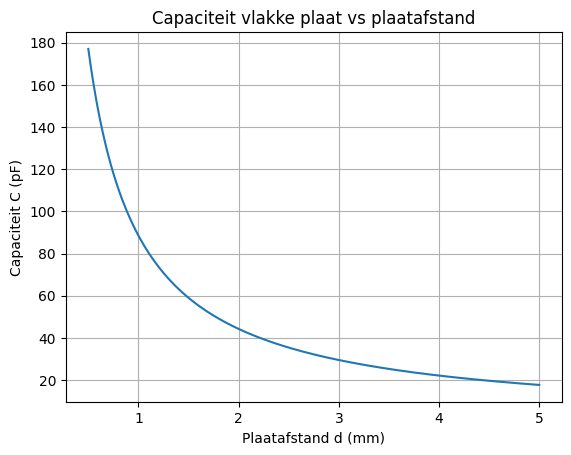

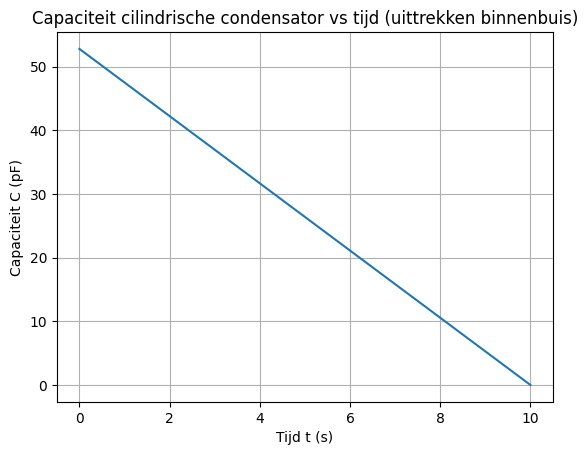

In [89]:
###
###Jouw code hier###
#1
def vlakkeplaat(A, d, eps_r=1.0):
    eps = eps_r * epsilon0
    return eps * A / d

# Gegevens vlakke plaat
A = 0.10 * 0.10              # m^2
d_vals = np.linspace(0.5e-3, 5e-3, 200)  # 0.5 mm → 5 mm

C_flat = vlakkeplaat(A, d_vals)

plt.figure()
plt.plot(d_vals*1e3, C_flat*1e12)
plt.xlabel("Plaatafstand d (mm)")
plt.ylabel("Capaciteit C (pF)")
plt.title("Capaciteit vlakke plaat vs plaatafstand")
plt.grid(True)
plt.show()

#2
def cilinder(a, b, L, eps_r=1.0):
    eps = eps_r * epsilon0
    return 2 * np.pi * eps * L / np.log(b / a)

# Gegevens cilinder
a = 9e-3 / 2      # m
b = 10e-3 / 2     # m
L0 = 0.10         # m
T = 10.0          # s

t_vals = np.linspace(0, T, 200)
L_vals = L0 * (1 - t_vals / T)   # lineair afnemende overlap
C_cyl = cilinder(a, b, L_vals)

plt.figure()
plt.plot(t_vals, C_cyl*1e12)
plt.xlabel("Tijd t (s)")
plt.ylabel("Capaciteit C (pF)")
plt.title("Capaciteit cilindrische condensator vs tijd (uittrekken binnenbuis)")
plt.grid(True)
plt.show()


###

## Stop hier met werken tot na de fysieke ontwerpopdracht in week 3.

### 6) Reflectie opdracht voor na de fysieke ontwerpopdracht


Als het goed is, heeft ieder teamlid van deze simulatie-opdracht een andere opstelling ontworpen hebben tijdens de fysieke ontwerpopdracht. Kies in goed overleg voor deze opdracht een van jullie twee ontwerpen.

Voeg hieronder eerst een foto in van je opstelling die je gekozen hebt.

Jullie gaan in deze opdracht het verschil tussen jullie voorspelde verband en jullie uiteindelijke verkregen kalibratie grafiek proberen te verklaren. Er zijn hiervoor drie mogelijke paden die jullie kunnen kiezen om te onderzoeken, Kies deel a, b of c en werk die volledig uit voor jullie ontwerp. Let op je hoeft er maar een uit te werken.

Verander de tekst hieronder zodat deze naar jouw foto verwijst. Zorg dat de foto in de map figures staat!
![figure 5.1](figures/opstelling_oscar_condensator.jpg)

#### Vraag 6a: Dunne laag niet meegerekende diëlektricum
Deze vraag is goed om te kiezen als je in je ontwerp een kleine laag extra materiaal hebt en deze tijdens de ontwerpopdracht niet hebben meegenomen in je theoretisch kalibratie grafiek.

1. Maak een nieuwe schets van je opstelling waarbij je de dikte van het extra diëlektricum meeneemt.
![figure 5.2](figures/opstelling_met_zakje.jpeg)
2. Leid de analytische oplossing af van de capaciteit van de hierboven getekende situatie.
![figure 5.3](figures/berekening_met_zakje.jpeg)
3. Programmeer de analytische oplossing in python.
4. Maak hierna een plot van het kalibratiegrafiek, oude en nieuwe analytische oplossing in een grafiek.
5. Beschrijf en verklaar de verschillen tussen de grafieken.
- De ontwerpgrafiek is een ideaal, te optimistisch model. het gaat uit van een linear verband tussen de capaciteit en het percentage water in een spons, waarbij het verband in werkelijkheid complexer is doordat de plastic laag ertussen wordt meeberkend. Dit zorgt ervoor dat bij dezelfde percentage water de capaciteit een stuk lager is, waardoor de niewe curve hoger ligt dan de eerste curve (zonder plastic laagje meet te nemen).



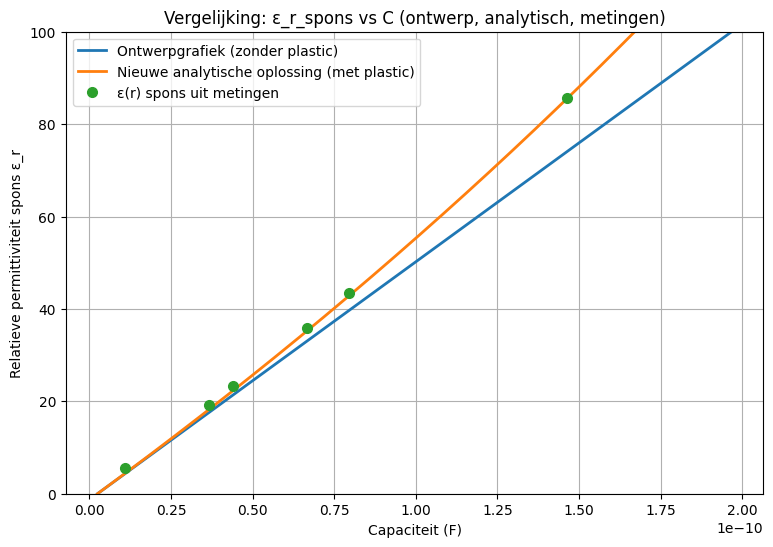

In [90]:
#3
import numpy as np
import matplotlib.pyplot as plt

eps0 = 8.854187817e-12  # F/m

def C_twee_lagen(A, dp, ds, eps_p, eps_s):
    """
    Capaciteit van twee diëlektrica in serie (plastic + spons).
    A     : oppervlak (m^2)
    dp    : dikte plastic (m)
    ds    : dikte spons (m)
    eps_p : relatieve permittiviteit plastic
    eps_s : relatieve permittiviteit spons (afhankelijk van waterpercentage)
    """
    return eps0 * A / (dp/eps_p + ds/eps_s)

#4

eps0 = 8.854187817e-12  # F/m

# Geometrie
A = 0.005
ds = 0.018
dp = 0.0001
eps_p = 2.5

# Functie: capaciteit van twee lagen in serie
def C_twee_lagen(A, dp, ds, eps_p, eps_s):
    return eps0 * A / (dp/eps_p + ds/eps_s)

# Functie: ε_r_spons uit gemeten capaciteit
def eps_spons_uit_C(C_meet, A, dp, ds, eps_p):
    term = (1/(C_meet)) - (dp/(eps0*eps_p*A))
    return ds / (term * eps0 * A)

# --- THEORETISCHE CURVES ---
eps_s_theorie = np.linspace(1, 80, 500)
percentage_water_theorie= np.linspace(0,100,500)
# Ontwerpgrafiek (zonder plastic)
C_ontwerp = eps0 * eps_s_theorie * A / ds

# Nieuwe analytische oplossing (met plastic)
C_nieuw = C_twee_lagen(A, dp, ds, eps_p, eps_s_theorie)

# --- METINGEN ---
C_meet = np.array([11.0,36.5,44.1,66.5,79.4,146.2,190.3])*1e-12
eps_s_meet = eps_spons_uit_C(C_meet, A, dp, ds, eps_p)
percentage_water_meet= (eps_s_meet/80)*100
# --- PLOT ---
plt.figure(figsize=(9,6))

plt.plot(C_ontwerp, percentage_water_theorie, label="Ontwerpgrafiek (zonder plastic)", linewidth=2)
plt.plot(C_nieuw, percentage_water_theorie, label="Nieuwe analytische oplossing (met plastic)", linewidth=2)
plt.plot(C_meet, percentage_water_meet, 'o', label="ε(r) spons uit metingen", markersize=7)

plt.xlabel("Capaciteit (F)")
plt.ylabel("Relatieve permittiviteit spons ε_r")
plt.title("Vergelijking: ε_r_spons vs C (ontwerp, analytisch, metingen)")
plt.grid(True)
plt.ylim(0,100)
plt.legend()
plt.show()





##### Antwoorden 6a

*Laat in deze cel je analytische oplossing met schets zien, dit mag met foto's of via LATEX.*

In [91]:
# Schrijf hier de code voor je oplossing. Gebruik hier je eerder gemaakte functies
# def condensator_extra_laag(#jouw variabelen): # Schrijf hier jouw functie
    ## je functie


### Maak hier je plot

##### Antwoorden 6a

*Beschrijf en verklaar je verschillen in deze markdown cel.*

#### Vraag 6b1: Lading op een condensator met het edge effect meegenomen

In deze opdracht gaan we verder in op het Edge effect en de invloed daarvan op de praktische capaciteit. Deze opdracht bouwt voort op de vraag 4.3.
Jullie hebben tijdens de ontwerpopdracht vierkante platen gebruikt in tegenstelling tot de ronde platen waarvoor de factoren in figure[label] zijn afgeleid. Er is onderzoek gedaan naar de factoren waarmee de praktische capaciteit vergeleken met de daadwerkelijke capaciteit verschilt dat onderzoek vind je hier: https://ieeexplore.ieee.org/stamp/stamp.jsp?tp=&arnumber=311759. Zoek in het onderzoek tabel 1 en formules 22 en 36 op.

1. Vergelijk de factor waarmee de schijf(disk) condensator verschilt met die van de vierkante plaat, kunnen we de vierkante plaat factor benaderen met de factor voor een disk condensator? Vergelijk het procentuele verschil tussen de factoren van de circulaire en vierkante platen, met de onzekerheden die in de meting zitten.



##### Antwoord 6b1

*Vergelijk hier de factoren tussen de circulaire en vierkante vlakke plaat condensatoren.*

#### Vraag 6b2: Capaciteit van een condensator met het edge effect meegenomen

Vanaf hier nemen we aan dat factor van de circulaire platen ongeveer gelijk is aan de factor voor vierkante platen. De factor die de capaciteit van de vlakke plaat approximatie linkt aan de werkelijke capaciteit noemen we vanaf nu de idealiteitsfactor.

1. Bereken de daadwerkelijke theoretische capaciteit van de condensator uit de sanity check 3 van de fysieke ontwerpopdracht en print deze op een nette manier.
2. Vergelijk dit met de daadwerkelijke theoretische capaciteit met de capaciteit die je op de dag zelf hebt gemeten.

Vanaf hier gaan we verder met jullie sensor van de ontwerpopdracht "Maak een sensor met condensatoren":

3. Reken je theoretische kalibratie grafiek om met de idealiteitsfactor.
4. Vergelijk je nieuwe theoretische kalibratiegrafiek van je praktische kalibratiegrafiek van de dag zelf.

In [92]:
# Schrijf hier jouw code die de vlakke plaat capaciteit omschrijft naar de werkelijke capaciteit

# def C_niet_ideaal(#relevante parameters):
    # Jouw berekeningen


##### Antwoorden 6b2

*Doe in deze markdown cel je vergelijkingen voor de sanity check condensator en je kalibratiegrafiek.*

#### Vraag 6c: Niet linear diëlektricum optie 1

Niet alle materialen zijn een lineair diëlektricum. Een aantal van de materialen die sterk niet lineair gedrag vertonen zijn: sponzen, foam & rubber. Als je in je opdracht een materiaal gebruikt heb waarvan je verwacht dat het verband sterk niet lineair is kan dit een hele goede opdracht zijn.
| Materiaal |$\chi_2$   |
| :-------------|:-------------|
| Spons|  |

Als jouw materiaal hier niet tussen staat dan kan je zelf op zoek naar een waarde van $\chi_2$ in de literatuur.

#### Vraag 6c1

1. Leidt het D veld van de condensator af uit de wet van Gauss.
2. Vindt een analytische uitdrukking voor het elektrisch veld in termen van het D veld.

##### Antwoorden 6c 1

*Antwoord vraag 6c 1.*

#### Vraag 6c2

1. Programmeer je oplossingen voor het D en E veld in python, gebruik het D veld uit je fysieke ontwerpopdracht.

Als je het elektrische veld van een vierkante vlakke plaat condensator weet kan je de capaciteit berekenen met de onderstaande formule:
$C = \frac{A
E_z \epsilon_0}{\Delta V}$

2. Plot de capaciteit van het niet lineaire diëlektricum, het theoretische kalibratiegrafiek en de uiteindelijke kalibratiegrafiek van de fysieke ontwerpopdracht.
3. Verklaar verschillen tussen de grafieken.

In [93]:
 # Pas deze code aan zodat jouw opstelling doorgerekend wordt
def E_condensator(x1, x2, D):
    return None

#### Vraag 7

Hoeveel van de afwijking tussen je metingen en je oorspronkelijke voorspelde kalibratiegrafiek wordt verklaard door wat je bij vraag 6 hebt uitgerekend? Kan je een (aantal) elektrisch veld en capaciteit gerelateerde reden(en) verzinnen wat de rest van de afwijking tussen meting en voorspelde kalibratiegrafiek kan verklaren.

##### Antwoorden 7

Offsetverschil: de gemeten capaciteit ligt duidelijk lager dan de oorspronkelijke ontwerpgrafiek → dat wordt heel goed verklaard door de extra laag plastic in serie (effectieve afstand groter, lage εr). Hellingsverschil: de gevoeligheid (hoeveel C toeneemt per % water) wordt ook kleiner door de plasticlaag, ook dat zie je terug in de nieuwe analytische lijn.

rest van de afwijkingen:
- Niet-uniform elektrisch veld:
De vlakke-plaatformule gaat uit van een homogeen veld tussen oneindig grote platen. In het echt heb je randvelden (fringing), vooral als de spons niet precies even groot is als de platen of niet perfect gecentreerd ligt.
- Niet-uniforme vochtverdeling in de spons:
Het water verdeelt zich niet perfect homogeen. Sommige delen zijn natter/droger waardoor de effectieve εr anders is dan je lineaire model aanneemt. Dit geeft spreiding en kleine niet-lineariteit.
- Luchtbelletjes en kleine holtes:
Tussen plastic en spons, of in de spons zelf, kunnen luchtbelletjes zitten (εr ≈ 1). Die verlagen lokaal de effectieve permittiviteit en dus de capaciteit
- Meetonzekerheid en ruis:
De Arduino‑meting heeft resolutie, ruis en jitter. Jij had al gezien dat de spreiding groter werd bij hogere capaciteit, dat past bij meer ruis/gevoeligheid bij grotere C.
- Draadjes, deBreadboard en Nabijgelegen geleiders voegen een kleine extra capaciteit toe.


